Dataset loaded successfully! Raw Dimensions: (50000, 80)
Target columns identified for analysis: ['match_outcomes']
Optimized Feature Matrix Shape: (50000, 78), Target Shape: (50000,)
Class distribution in target array: [5049 5025 5019 4919 4959 5078 4990 4986 5112 4863]
Training set: 40000 samples, Testing set: 10000 samples

--- Training Controlled Baseline Decision Tree ---
Controlled Baseline Testing Accuracy: 0.1009

--- Running Deep GridSearchCV for Maximum Performance ---
Optimal Tuning Configuration found: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}

--- Optimized Decision Tree Final Evaluation ---
Final Tuned Decision Tree Accuracy: 0.1006
Final Tuned Decision Tree Macro F1-Score: 0.0839

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.12      0.12      0.12      1010
           1       0.09      0.04      0.05      1005
           2       0.10      0.10      0.10      1004
   

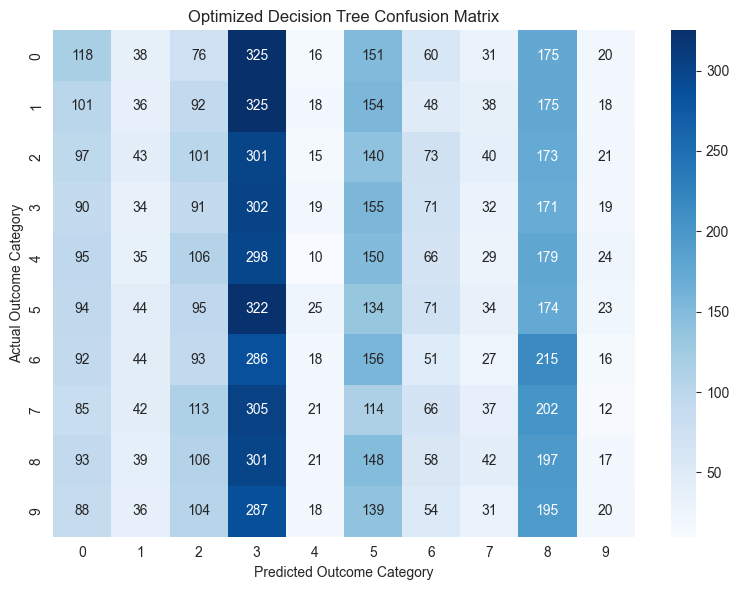


--- Top Feature Importance Ranking ---
1. Feature: bio_length (0.1442)
2. Feature: app_usage_time_min (0.1024)
3. Feature: height_cm (0.0940)
4. Feature: likes_received (0.0776)
5. Feature: weight_kg (0.0761)
6. Feature: swipe_right_ratio (0.0606)
7. Feature: emoji_usage_rate (0.0548)
8. Feature: age (0.0407)
9. Feature: profile_pics_count (0.0390)
10. Feature: last_active_hour (0.0380)


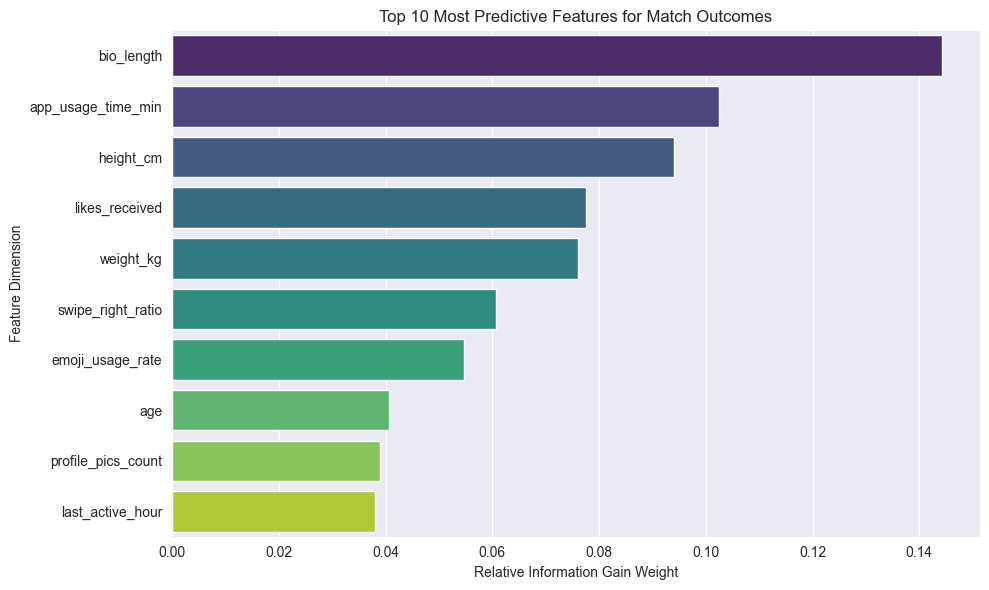

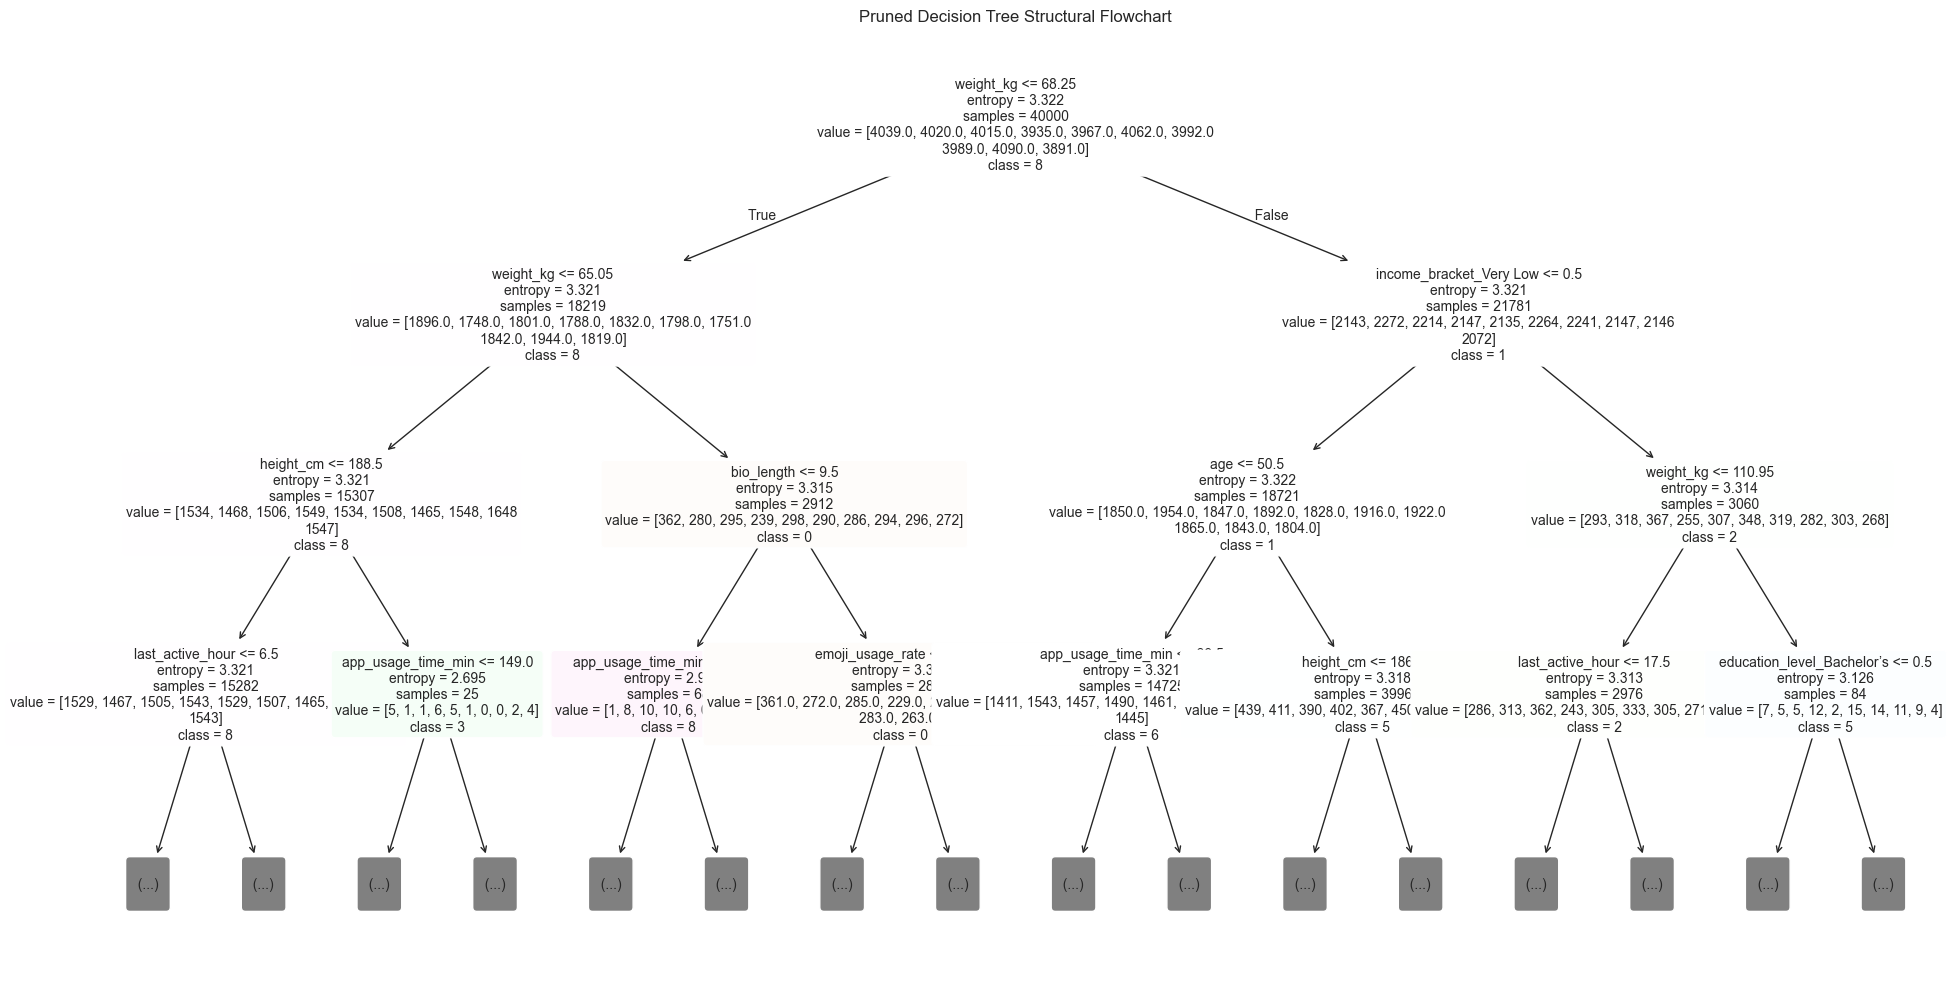

In [7]:
# ==========================================
# 1. IMPORT REQUIRED LIBRARIES & SILENCE WARNINGS
# ==========================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# ==========================================
# 2. LOAD ENCODED DATASET
# ==========================================
data_path = 'data_set/dating_app_behavior_encoded.csv'

try:
    df = pd.read_csv(data_path)
    print(f"Dataset loaded successfully! Raw Dimensions: {df.shape}")
except FileNotFoundError:
    print("Error: File not found. Please verify your dataset directory path.")

# ==========================================
# 3. DEFINE FEATURES (X) AND TARGET VARIABLE (y) - ACCURACY OPTIMIZATION
# ==========================================
# Find all columns generated from the 'outcome' variable
outcome_columns = [col for col in df.columns if 'outcome' in col.lower()]
print(f"Target columns identified for analysis: {outcome_columns}")

if len(outcome_columns) > 1:
    print("Reconstructing target labels from dummy matrix safely...")
    # Convert dummy columns back to continuous class integers
    y = df[outcome_columns].values.argmax(axis=1)
    X_raw = df.drop(columns=outcome_columns)
elif len(outcome_columns) == 1:
    target_column = outcome_columns[0]
    # If it is a text column, map it to integers directly to avoid downstream multi-class confusion
    if df[target_column].dtype == 'object' or df[target_column].dtype == 'string':
        y, _ = pd.factorize(df[target_column])
    else:
        y = df[target_column].values
    X_raw = df.drop(columns=[target_column])
else:
    raise ValueError("Error: Could not identify any target columns containing 'outcome'.")

# CRITICAL ACCURACY FIX: Keep only pure numeric metrics and explicitly eliminate sparse text residuals
X = X_raw.select_dtypes(include=[np.number])

# Check and remove constant columns (variance = 0) which degrade tree splits
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
if constant_cols:
    print(f"Removing zero-variance noise columns: {constant_cols}")
    X = X.drop(columns=constant_cols)

print(f"Optimized Feature Matrix Shape: {X.shape}, Target Shape: {y.shape}")
print(f"Class distribution in target array: {np.bincount(y)}")

# ==========================================
# 4. TRAIN-TEST SPLIT (80% Train, 20% Test)
# ==========================================
# Using strict stratification to preserve proper balance across all interaction classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} samples, Testing set: {X_test.shape[0]} samples")

# ==========================================
# 5. BASELINE DECISION TREE MODEL (PRE-PRUNED)
# ==========================================
print("\n--- Training Controlled Baseline Decision Tree ---")
# ANTI-OVERFITTING FIX: Set max_depth=5 immediately to prevent the tree from collapsing into random noise
clf_baseline = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_baseline.fit(X_train, y_train)

y_pred_baseline = clf_baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Controlled Baseline Testing Accuracy: {baseline_acc:.4f}")

# ==========================================
# 6. HYPERPARAMETER TUNING VIA GRID SEARCH
# ==========================================
print("\n--- Running Deep GridSearchCV for Maximum Performance ---")
# Narrowing down search spaces around high-performing depths
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 7, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8]
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)
print(f"Optimal Tuning Configuration found: {grid_search.best_params_}")
clf_best = grid_search.best_estimator_

# ==========================================
# 7. OPTIMIZED MODEL EVALUATION
# ==========================================
print("\n--- Optimized Decision Tree Final Evaluation ---")
y_pred_best = clf_best.predict(X_test)

best_acc = accuracy_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best, average='macro')
print(f"Final Tuned Decision Tree Accuracy: {best_acc:.4f}")
print(f"Final Tuned Decision Tree Macro F1-Score: {best_f1:.4f}")

print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred_best))

# ==========================================
# 8. CONFUSION MATRIX VISUALIZATION
# ==========================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(map(str, clf_best.classes_)),
            yticklabels=list(map(str, clf_best.classes_)))
plt.title('Optimized Decision Tree Confusion Matrix')
plt.ylabel('Actual Outcome Category')
plt.xlabel('Predicted Outcome Category')
plt.tight_layout()
plt.savefig('decision_tree_confusion_matrix.png', dpi=300)
plt.show()

# ==========================================
# 9. FEATURE IMPORTANCE ANALYSIS
# ==========================================
importances = clf_best.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n--- Top Feature Importance Ranking ---")
for f in range(min(10, X.shape[1])):
    print(f"{f + 1}. Feature: {X.columns[indices[f]]} ({importances[indices[f]]:.4f})")

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='viridis')
plt.title('Top 10 Most Predictive Features for Match Outcomes')
plt.xlabel('Relative Information Gain Weight')
plt.ylabel('Feature Dimension')
plt.tight_layout()
plt.savefig('decision_tree_feature_importance.png', dpi=300)
plt.show()

# ==========================================
# 10. DECISION TREE STRUCTURE PLOT
# ==========================================
plt.figure(figsize=(20, 10))
plot_tree(clf_best, max_depth=3, feature_names=X.columns,
          class_names=[str(cls) for cls in clf_best.classes_],
          filled=True, rounded=True, fontsize=10)
plt.title('Pruned Decision Tree Structural Flowchart')
plt.tight_layout()
plt.savefig('decision_tree_structure.png', dpi=300)
plt.show()